<a href="https://colab.research.google.com/github/ClaretWheel1481/Artificial-Intelligence/blob/main/DeepLearning/LeNet%E7%BD%91%E7%BB%9C%E5%AE%9E%E7%8E%B0CIFAR10%E5%88%86%E7%B1%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
# 数据预处理
data_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))
])

In [ ]:
# 加载数据
train_datasets = datasets.CIFAR10(root='./data',train=True,transform=data_tf,download=True)
test_datasets = datasets.CIFAR10(root='./data',train=False,transform=data_tf,download=True)

100%|██████████| 170M/170M [00:04<00:00, 41.1MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
# 对数据进行分批次
train_loader = DataLoader(dataset=train_datasets,batch_size=64,shuffle=True)
test_loader = DataLoader(dataset=test_datasets,batch_size=64,shuffle=True)

In [ ]:
def un_normalize(img,mean,dev):
    if img.dim()==3:
      R = img.numpy()[0,:,:] * dev[0] + mean[0]
      G = img.numpy()[1,:,:] * dev[1] + mean[1]
      B = img.numpy()[2,:,:] * dev[2] + mean[2]

      RGB = np.stack((R,G,B),axis=2)
      return RGB
    else:
      for im in img:
        R = im[0,:,:] * dev[0] + mean[0]
        G = im[1,:,:] * dev[1] + mean[1]
        B = im[2,:,:] * dev[2] + mean[2]
        RGB = np.stack((R,G,B),axis=2)
        imgs.append(RGB)
      return imgs


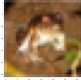

In [ ]:
class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10),dpi=10)

img,label = train_datasets[0]
img = un_normalize(img,(0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))
plt.imshow(img)

In [ ]:
dataiter = iter(train_loader)
imgs,labels = next(dataiter)

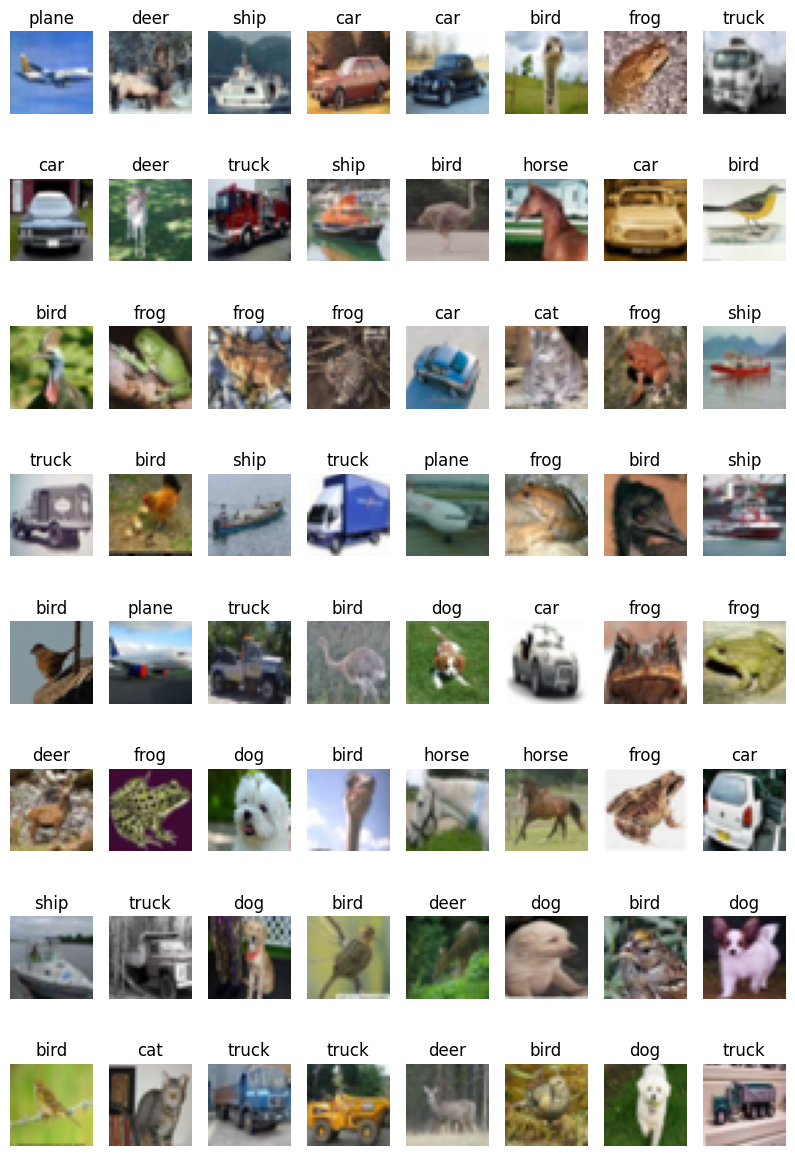

In [ ]:
fig,ax = plt.subplots(nrows=8,ncols=8,figsize=(10,15))
for i in range(8):
  for j in range(8):
    ax[i][j].imshow(un_normalize(imgs[i*8+j],(0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616)))
    ax[i][j].set_title(class_names[labels[i*8+j]])
    ax[i][j].axis('off')

In [ ]:
class ConvNet(torch.nn.Module):
  def __init__(self):
    super().__init__()
    # 卷积层
    self.conv1 = torch.nn.Conv2d(in_channels=3,out_channels=6,kernel_size=5,stride=1,padding='valid')
    self.conv2 = torch.nn.Conv2d(in_channels=6,out_channels=16,kernel_size=5,stride=1,padding='valid')

    # 池化层
    self.max_pool = torch.nn.MaxPool2d(kernel_size=(2,2),stride=2)

    # 激活函数
    self.relu = torch.nn.ReLU()

    # 全连接层
    self.layer1 = torch.nn.Linear(in_features=16*5*5,out_features=120)
    self.layer2 = torch.nn.Linear(in_features=120,out_features=84)
    self.layer3 = torch.nn.Linear(in_features=84,out_features=10)

  def forward(self,x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.max_pool(x)

    x = self.conv2(x)
    x = self.relu(x)
    x = self.max_pool(x)

    x = x.view(x.size(0),-1)

    x = self.layer1(x)
    x = self.relu(x)

    x = self.layer2(x)
    x = self.relu(x)

    x = self.layer3(x)
    return x

In [ ]:
from torchsummary import summary

net = ConvNet()
summary(net,(3,32,32),device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
              ReLU-2            [-1, 6, 28, 28]               0
         MaxPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
              ReLU-5           [-1, 16, 10, 10]               0
         MaxPool2d-6             [-1, 16, 5, 5]               0
            Linear-7                  [-1, 120]          48,120
              ReLU-8                  [-1, 120]               0
            Linear-9                   [-1, 84]          10,164
             ReLU-10                   [-1, 84]               0
           Linear-11                   [-1, 10]             850
Total params: 62,006
Trainable params: 62,006
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/ba

In [ ]:
# 损失函数和优化器
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(),lr=0.001)

In [ ]:
from tqdm import tqdm

# 模型训练
for epoch in range(10):
  losses = []

  loop = tqdm(enumerate(train_loader),total=len(train_loader))

  for step,data in loop:
    imgs,labels = data
    imgs = imgs.cuda()
    labels = labels.cuda()
    net.cuda()

    outs = net(imgs)
    loss = criterion(outs,labels)
    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loop.set_description(f'Epoch [{epoch+1}/10]')
    loop.set_postfix(loss=np.mean(losses))

Epoch [10/10]: 100%|██████████| 782/782 [00:21<00:00, 37.20it/s, loss=0.587]


In [ ]:
net.eval()

correct = 0

for data in test_loader:
    imgs,labels = data
    imgs = imgs.cuda()
    labels = labels.cuda()
    net.cuda()

    outs = net(imgs)

    pred = torch.argmax(outs,1)
    correct += (pred == labels).sum()

print(f"correct: {correct/len(test_datasets)}")

correct: 0.6381999850273132


In [ ]:
test_imgs,labels = next(iter(train_loader))

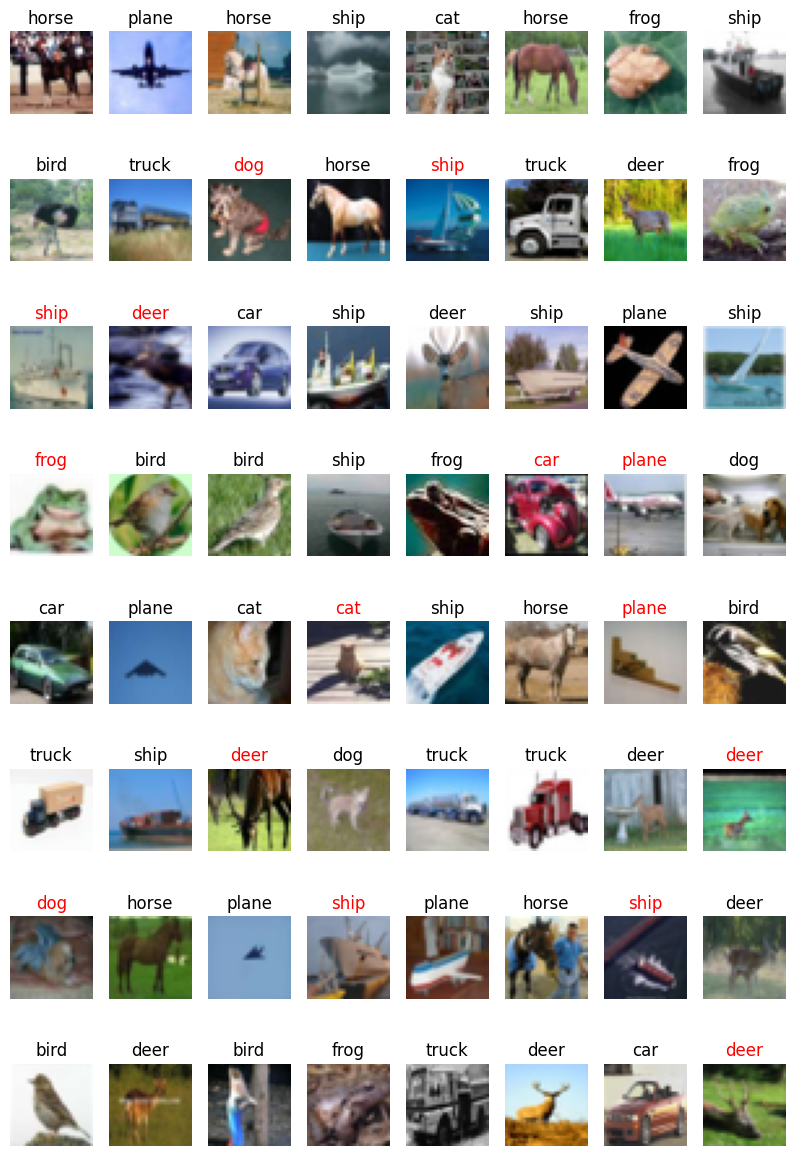

In [ ]:
outputs = net(test_imgs.cuda())
pred = torch.argmax(outputs,1)

fig,ax = plt.subplots(nrows=8,ncols=8,figsize=(10,15))

for i in range(8):
  for j in range(8):
    ax[i][j].imshow(un_normalize(test_imgs[i*8+j],(0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616)))
    ax[i][j].axis('off')
    if pred[i*8+j] == labels[i*8+j]:
      ax[i][j].set_title(class_names[pred[i*8+j]])
    else:
      ax[i][j].set_title(f'{class_names[labels[i*8+j]]}',color='red')